In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pylie import SE3, SO3, R3, SE23
from ins_observer import ComplementaryINS
import scipy

### Load data

In [2]:
def get_from_df(df, column_prefix, dims, step):
    # odom
    #   pose (x,y,z)
    #   orientation (x,y,z,w)
    #   twist
    #       linear velocity (x,y,z)
    #       angular velocity (x,y,z)
    # imu
    #   linear (x,y,z)
    #   angular (x,y,z)
    #   orientation (x,y,z,w)
    return df.iloc[step][[f"{column_prefix}_{d}" for d in dims]]


sim_speed_multiplier = 1
dt = 0.001 * sim_speed_multiplier
hz = 30
dt = float(1 / hz) * sim_speed_multiplier
# df = pd.read_csv("combined_data_with_velocity.csv")
df = pd.read_csv("combined_data_30Hz.csv")
# df = pd.read_csv("combined_data.csv")
df = df.iloc[::sim_speed_multiplier].reset_index(drop=True)
time_lim = len(df)
print(f"{time_lim=}")

time_lim=2547


### Calculations to get observer measurements

In [3]:
def rpy_from_quat(quat):
    rpys = []
    for q in quat:
        rpy = SO3.from_list(q, format_spec="q").as_euler(
            seq="xyz", degrees=False
        )
        rpys.append(rpy)
    return np.asarray(rpys)


def rotations_from_quat(quat):
    rpys = []
    for q in quat:
        rpy = SO3.from_list(q, format_spec="q").as_matrix()
        rpys.append(rpy)
    return np.asarray(rpys)


quat = get_from_df(
    df, "odom_orientation", ["x", "y", "z", "w"], slice(time_lim)
)
robot_2_global = rotations_from_quat(quat.to_numpy())
vel_robot_frame = get_from_df(
    df, "cmd_vel_linear", ["x", "y", "z"], slice(time_lim)
).to_numpy()
vel_global = np.einsum("bij,bj->bi", robot_2_global, vel_robot_frame)


df["odom_vel_x"] = vel_global[:, 0]
df["odom_vel_y"] = vel_global[:, 1]
df["odom_vel_z"] = vel_global[:, 2]

### Add artificial noise

In [9]:
def add_noise(data, cov, bias_walk_cov=None):
    N = data.shape[0]
    noise = np.random.multivariate_normal(np.zeros(3), cov, N)
    out = data + noise
    if bias_walk_cov is not None:
        bias = np.random.multivariate_normal(
            np.zeros(3), bias_walk_cov, size=N
        )
        accumulated_bias = np.cumsum(bias, axis=0)
        out += accumulated_bias
    return out


def add_rotation_noise(data, yaw_noise):
    data_arr = np.asarray(data)
    N = data.shape[0]
    noisy_data = []
    for n in range(N):
        perfect_rot = SO3.from_list(
            data_arr[n], format_spec="q"
        ).as_euler()

        noisy_rot_eul = perfect_rot.copy()
        noisy_rot_eul[2] += np.random.normal(0, yaw_noise)
        noisy_rotation_quat = SO3.from_euler(
            noisy_rot_eul
        ).as_quaternion()
        noisy_data.append(noisy_rotation_quat)
    return np.asarray(noisy_data)


noise_imu_gyr = np.diag([0, 0, 0.05])
noise_imu_acc = np.diag([0.005, 0.005, 0.005])
noise_imu_gyr_walk_cov = np.diag([0.00001, 0.00001, 0.00001])
# noise_imu_gyr_walk_cov = np.diag([0, 0, 0])
noise_imu_acc_walk_cov = np.diag([0.00001, 0.00001, 0.00001])
# noise_imu_acc_walk_cov = np.diag([0, 0, 0])

noise_observer_pos = np.eye(3) * 0.01
noise_observer_vel = np.eye(3) * 0.01
noise_observer_mag = 2
imu_gyr = df[
    ["imu_angular_vel_x", "imu_angular_vel_y", "imu_angular_vel_z"]
]
df[
    [
        "imu_angular_vel_x_noisy",
        "imu_angular_vel_y_noisy",
        "imu_angular_vel_z_noisy",
    ]
] = add_noise(imu_gyr, noise_imu_gyr)

imu_acc = df[
    ["imu_linear_acc_x", "imu_linear_acc_y", "imu_linear_acc_z"]
]
df[
    [
        "imu_linear_acc_x_noisy",
        "imu_linear_acc_y_noisy",
        "imu_linear_acc_z_noisy",
    ]
] = add_noise(imu_acc, noise_imu_acc)

observer_pos = df[["odom_pose_x", "odom_pose_y", "odom_pose_z"]]
df[
    ["odom_pose_x_noisy", "odom_pose_y_noisy", "odom_pose_z_noisy"]
] = add_noise(observer_pos, noise_observer_pos)

observer_vel = df[["odom_vel_x", "odom_vel_y", "odom_vel_z"]]
df[["odom_vel_x_noisy", "odom_vel_y_noisy", "odom_vel_z_noisy"]] = (
    add_noise(observer_vel, noise_observer_vel)
)

magn = df[
    [
        "odom_orientation_x",
        "odom_orientation_y",
        "odom_orientation_z",
        "odom_orientation_w",
    ]
]
df[
    [
        "odom_orientation_noisy_x",
        "odom_orientation_noisy_y",
        "odom_orientation_noisy_z",
        "odom_orientation_noisy_w",
    ]
] = add_rotation_noise(magn, noise_observer_mag)

### Trajectory

(np.float64(-2.9664111751631843),
 np.float64(5.641032647811884),
 np.float64(-0.12412931602217087),
 np.float64(4.257671647227797))

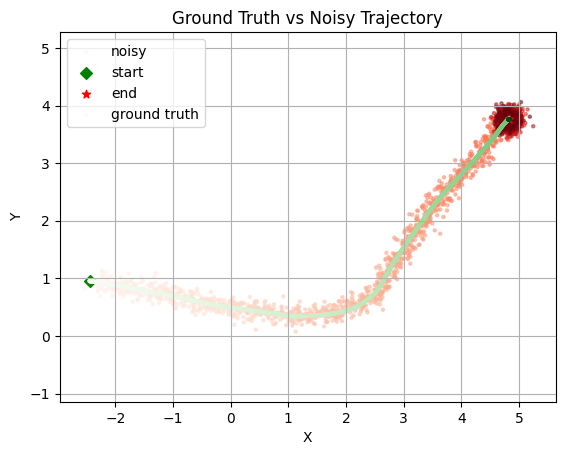

In [10]:
fig, ax = plt.subplots()

noisy_x = df["odom_pose_x_noisy"].to_numpy()
noisy_y = df["odom_pose_y_noisy"].to_numpy()
ax.scatter(
    noisy_x,
    noisy_y,
    c=list(range(time_lim)),
    s=5,
    label="noisy",
    cmap="Reds",
    alpha=0.5,
)

x = df["odom_pose_x"].to_numpy()
y = df["odom_pose_y"].to_numpy()
ax.scatter(x[0], y[0], label="start", marker="D", color="g")
ax.scatter(x[-1], y[-1], label="end", marker="*", color="r")
ax.scatter(
    x,
    y,
    c=list(range(time_lim)),
    s=5,
    label="ground truth",
    cmap="Greens",
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Ground Truth vs Noisy Trajectory")
ax.legend()
ax.grid(True)
ax.axis("equal")

Text(0.5, 0.98, 'External Observer Measurments (GNSS)')

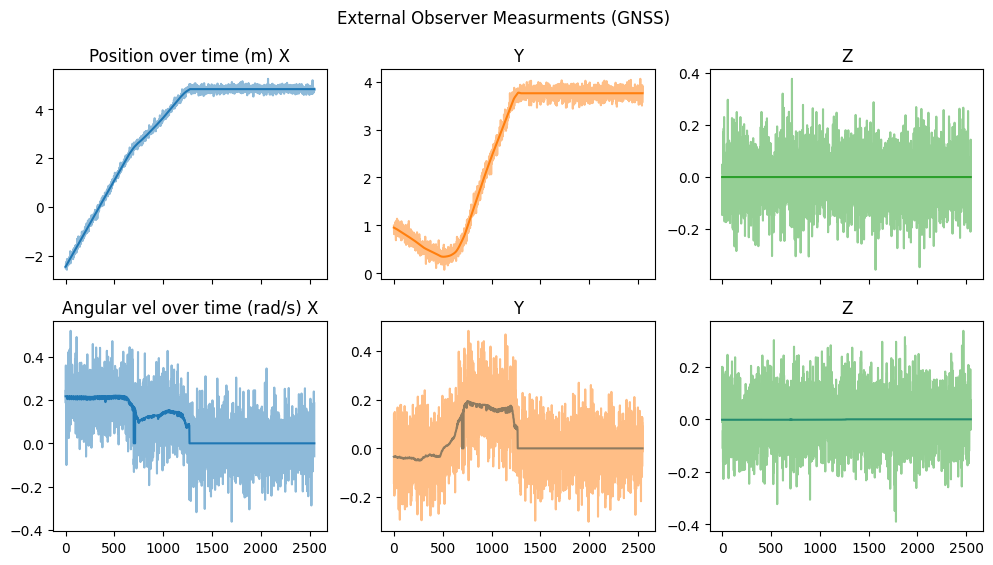

In [11]:
plt.close("all")
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)

axes[0, 0].plot(df["odom_pose_x"], color="C0")
axes[0, 1].plot(df["odom_pose_y"], color="C1")
axes[0, 2].plot(df["odom_pose_z"], color="C2")
axes[0, 0].plot(df["odom_pose_x_noisy"], alpha=0.5, color="C0")
axes[0, 1].plot(df["odom_pose_y_noisy"], alpha=0.5, color="C1")
axes[0, 2].plot(df["odom_pose_z_noisy"], alpha=0.5, color="C2")
axes[0, 0].set_title("Position over time (m) X")
axes[0, 1].set_title("Y")
axes[0, 2].set_title("Z")

axes[1, 0].plot(df["odom_vel_x"])
axes[1, 1].plot(df["odom_vel_y"])
axes[1, 2].plot(df["odom_vel_z"])
axes[1, 0].plot(df["odom_vel_x_noisy"], alpha=0.5, color="C0")
axes[1, 1].plot(df["odom_vel_y_noisy"], alpha=0.5, color="C1")
axes[1, 2].plot(df["odom_vel_z_noisy"], alpha=0.5, color="C2")
axes[1, 0].set_title("Angular vel over time (rad/s) X")
axes[1, 1].set_title("Y")
axes[1, 2].set_title("Z")

fig.suptitle(f"External Observer Measurments (GNSS)")

Text(0.5, 0.98, 'Onboard IMU measurements')

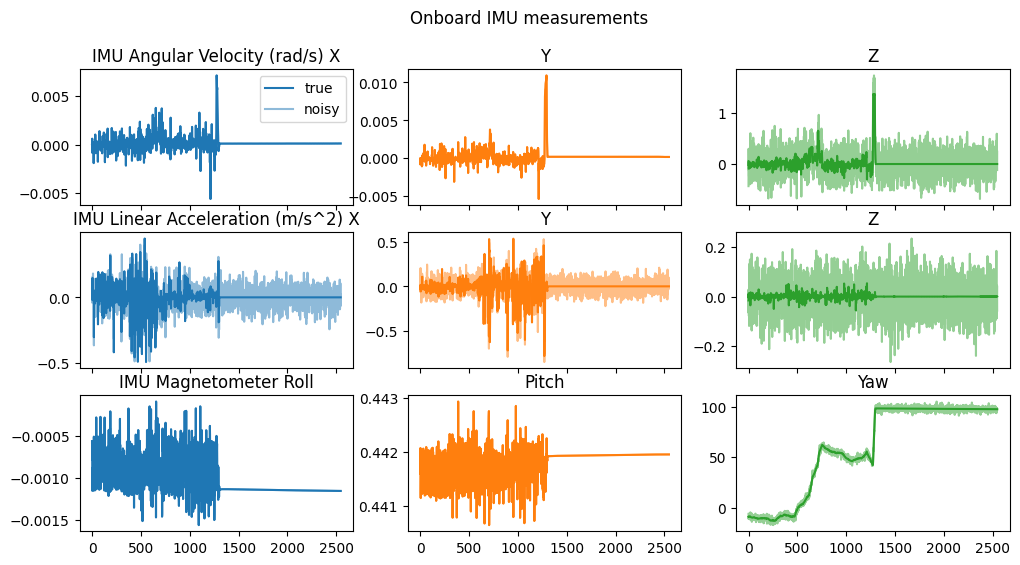

In [ ]:
plt.close("all")
fig, axes = plt.subplots(3, 3, figsize=(12, 6), sharex=True)

axes[0, 0].plot(df["imu_angular_vel_x"], label="true", color="C0")
axes[0, 1].plot(df["imu_angular_vel_y"], color="C1")
axes[0, 2].plot(df["imu_angular_vel_z"], color="C2")
axes[0, 0].plot(
    df["imu_angular_vel_x_noisy"],
    label="noisy",
    alpha=0.5,
    color="C0",
)
axes[0, 1].plot(df["imu_angular_vel_y_noisy"], alpha=0.5, color="C1")
axes[0, 2].plot(df["imu_angular_vel_z_noisy"], alpha=0.5, color="C2")
axes[0, 0].legend()
axes[0, 0].set_title("IMU Angular Velocity (rad/s) X")
axes[0, 1].set_title("Y")
axes[0, 2].set_title("Z")

axes[1, 0].plot(df["imu_linear_acc_x"], color="C0")
axes[1, 1].plot(df["imu_linear_acc_y"], color="C1")
axes[1, 2].plot(df["imu_linear_acc_z"], color="C2")
axes[1, 0].plot(df["imu_linear_acc_x_noisy"], alpha=0.5, color="C0")
axes[1, 1].plot(df["imu_linear_acc_y_noisy"], alpha=0.5, color="C1")
axes[1, 2].plot(df["imu_linear_acc_z_noisy"], alpha=0.5, color="C2")
axes[1, 0].set_title("IMU Linear Acceleration (m/s^2) X")
axes[1, 1].set_title("Y")
axes[1, 2].set_title("Z")

orient_quat = df[
    [
        "odom_orientation_x",
        "odom_orientation_y",
        "odom_orientation_z",
        "odom_orientation_w",
    ]
].to_numpy()
orient_euler = []
for o_q in orient_quat:
    orient_euler.append(
        SO3.from_list(o_q, format_spec="q").as_euler()
    )
orient_euler = np.asarray(orient_euler)

orient_euler_noisy = []
orient_quat_noisy = df[
    [
        "odom_orientation_noisy_x",
        "odom_orientation_noisy_y",
        "odom_orientation_noisy_z",
        "odom_orientation_noisy_w",
    ]
].to_numpy()
for o_q_n in orient_quat_noisy:
    orient_euler_noisy.append(
        SO3.from_list(o_q_n, format_spec="q").as_euler()
    )
orient_euler_noisy = np.asarray(orient_euler_noisy)

axes[2, 0].plot(orient_euler[:, 0], color="C0")
axes[2, 1].plot(orient_euler[:, 1], color="C1")
axes[2, 2].plot(orient_euler[:, 2], color="C2")

axes[2, 0].plot(orient_euler_noisy[:, 0], color="C0", alpha=0.5)
axes[2, 1].plot(orient_euler_noisy[:, 1], color="C1", alpha=0.5)
axes[2, 2].plot(orient_euler_noisy[:, 2], color="C2", alpha=0.5)

axes[2, 0].set_title("IMU Magnetometer Roll")
axes[2, 1].set_title("Pitch")
axes[2, 2].set_title("Yaw")

fig.suptitle(f"Onboard IMU measurements")